Import packages and data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import yfinance as yf

Import Bitcoin daily data

In [2]:
data = yf.download("BTC-USD", start="2023-01-01", interval="1d")

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [3]:
def getcoin(coin_df):
    # 1. Flatten the MultiIndex (removes the 'BTC-USD' level)
    df_adj = coin_df.copy()
    if isinstance(df_adj.columns, pd.MultiIndex):
        df_adj.columns = df_adj.columns.get_level_values(0)
    
    # 2. Move 'date' from the index to a column
    df_adj = df_adj.reset_index()
    df_adj.rename(columns={'Date': 'Date'}, inplace=True)
    
    # 3. Return order: date, close, high, low, open, volume
    return df_adj[['Date', 'Close', 'High', 'Low', 'Open', 'Volume']]

In [4]:
# Usage:
df = getcoin(data)
df

Price,Date,Close,High,Low,Open,Volume
0,2023-01-01,16625.080078,16630.439453,16521.234375,16547.914062,9244361700
1,2023-01-02,16688.470703,16759.343750,16572.228516,16625.509766,12097775227
2,2023-01-03,16679.857422,16760.447266,16622.371094,16688.847656,13903079207
3,2023-01-04,16863.238281,16964.585938,16667.763672,16680.205078,18421743322
4,2023-01-05,16836.736328,16884.021484,16790.283203,16863.472656,13692758566
...,...,...,...,...,...,...
1186,2026-04-01,68078.554688,69230.359375,67555.359375,68232.890625,36465393617
1187,2026-04-02,66888.570312,68633.148438,65725.257812,68077.898438,39323384518
1188,2026-04-03,66931.101562,67296.234375,66281.539062,66889.015625,22815543346
1189,2026-04-04,67290.515625,67515.015625,66769.640625,66938.648438,15878814963


Creating Class for grid trading strategy

In [5]:
class GridStrategy:
    def __init__(self, initial_money, lower_bound, upper_bound, grid_count, commission=0.004):
        self.money = initial_money
        self.initial_money = initial_money
        self.commission = commission
        
        # Grid Setup
        self.grid_lines = np.linspace(lower_bound, upper_bound, grid_count)
        self.on_coin_portions = [1 - i/(grid_count - 1) for i in range(grid_count)]
        self.on_coin_values = [p * initial_money for p in self.on_coin_portions]
        
        # State Tracking
        self.last_on_coin_value = 0 # lastoc
        self.last_coin_num = 0      # lastcoinnum
        self.start_position = 0     # startposition

    def find_grid_line(self, close_previous, close_new):
        """Grid crossing logic."""
        result = 0
        for l in self.grid_lines:
            if close_previous < l:
                if close_new < l:
                    break
                elif close_new >= l:
                    result = l
            elif close_previous == l:
                result = l
            elif close_previous > l:
                if close_new > l:
                    continue
                elif close_new <= l:
                    result = l
        return result

    def get_portion_index(self, price):
        """Find the grid level index."""
        count = 0
        for i in self.grid_lines:
            if price != i and price > i:
                count += 1
        if price > self.grid_lines[-1]:
            count -= 1
        return count

    def generate_coin_prices(self, df):
        """
        Replicates  the 'Coin_Price' column.
        Handles the first row check and the subsequent loop.
        """
        coin_price = []

        # Check first row (index 0)
        if df.Close.iloc[0] in self.grid_lines:
            coin_price.append(df.Close.iloc[0])
        else:
            coin_price.append(0)

        # Loop through the rows starting from index 1
        for i in range(1, len(df)):
            hit = self.find_grid_line(df.Close.iloc[i - 1], df.Close.iloc[i])
            coin_price.append(hit)
            
        return coin_price

    def execute_backtest(self, df):
        """
        Executes the strategy using the generated Coin_Price column.
        """
        # 1. Generate the Coin_Price list when trigger buing or selling process
        df = df.copy()
        df['Coin_Price'] = self.generate_coin_prices(df)
        
        on_coin = []
        cash_flow_on_coin = []
        coin_num = []
        cash = []
        
        # 2. Iterate through Coin_Price 
        for i in df.Coin_Price:
            if i == 0:
                if self.start_position == 0:
                    on_coin.append(0)
                    cash_flow_on_coin.append(0)
                    coin_num.append(0)
                    cash.append(self.money)
                else:
                    # 'portion' is maintained from the last successful hit
                    on_coin.append(self.on_coin_values[portion])
                    cash_flow_on_coin.append(0)
                    coin_num.append(self.last_coin_num)
                    cash.append(self.money)
            else:
                portion = self.get_portion_index(i)
                on_coin.append(self.on_coin_values[portion])

                # Cash Flow
                if i != self.last_on_coin_value:
                    temp_cash = self.on_coin_values[portion] - self.last_on_coin_value
                    cash_flow_on_coin.append(temp_cash)
                    self.last_on_coin_value = self.on_coin_values[portion]
                else:
                    cash_flow_on_coin.append(0)

                # Coin Number & Cash
                if self.start_position == 0:
                    self.last_coin_num = round(self.on_coin_values[portion] * (1 - self.commission) / i, 8)
                    self.money -= self.on_coin_values[portion]
                    self.start_position = 1
                else:
                    if i != self.last_on_coin_value or 'temp_cash' in locals():
                        if temp_cash > 0: # Buy
                            self.last_coin_num = round(temp_cash * (1 - self.commission) / i, 8) + self.last_coin_num
                        else: # Sell
                            self.last_coin_num = round(temp_cash * (1 + self.commission) / i, 8) + self.last_coin_num
                        self.money -= temp_cash
                
                coin_num.append(self.last_coin_num)
                cash.append(self.money)

        # Update DataFrame
        df['On_Coin'] = on_coin
        df['CF_On_Coin'] = cash_flow_on_coin
        df['Coin_Num'] = coin_num
        df['Cash'] = cash
        df['Total_Asset'] = round(df['Coin_Num'] * df['Close'] + df['Cash'], 2)
        
        return df
    
    def analyze_performance(self, dftest):
        """
        Plots the total asset curve and calculates the return rate.
        """
        plt.figure(figsize=(12, 8))
        plt.plot(dftest['Total_Asset'], label='Total Asset Value', color='blue')
        plt.title('Grid Trading Strategy: Total Asset Value Over Time')
        plt.xlabel('Time Step')
        plt.ylabel('Value (USD)')
        plt.legend()
        plt.grid(True)
        plt.show()

        latestAssetValue = dftest['Total_Asset'].iloc[-1]
        return_rate = round((latestAssetValue / self.initial_money - 1) * 100, 2)
        
        print(f"The return rate is {return_rate}%")
        return latestAssetValue

In [6]:
data = yf.download("BTC-USD", start="2023-01-01", interval="1d")

[*********************100%***********************]  1 of 1 completed


In [20]:
# --- Implementation Example ---
bot = GridStrategy(12000, 10000, 130000, 13) #Initial Principal, lower bound, upper bound, grid line number
final_results = bot.execute_backtest(df)

In [21]:
final_results[final_results['CF_On_Coin'] != 0]

Price,Date,Close,High,Low,Open,Volume,Coin_Price,On_Coin,CF_On_Coin,Coin_Num,Cash,Total_Asset
13,2023-01-14,20976.298828,21075.142578,19907.828125,19910.537109,38967784639,20000.0,11000.0,11000.0,0.547800,1000.0,12490.82
100,2023-04-11,30235.058594,30509.083984,29609.300781,29653.679688,20121259843,30000.0,10000.0,-1000.0,0.514333,2000.0,17550.90
337,2023-12-04,41980.097656,42371.750000,39978.628906,39978.628906,39856129827,40000.0,9000.0,-1000.0,0.489233,3000.0,23538.06
409,2024-02-14,51826.695312,52021.371094,49296.832031,49733.445312,39105608050,50000.0,8000.0,-1000.0,0.469153,4000.0,28314.67
423,2024-02-28,62504.789062,63913.132812,56738.425781,57071.097656,83239156760,60000.0,7000.0,-1000.0,0.452420,5000.0,33278.42
435,2024-03-11,72123.906250,72850.710938,67194.882812,69020.546875,65716656765,70000.0,6000.0,-1000.0,0.438077,6000.0,37595.83
486,2024-05-01,58254.011719,60780.500000,56555.292969,60609.496094,48439780271,60000.0,7000.0,1000.0,0.454677,5000.0,31486.77
505,2024-05-20,71448.195312,71483.562500,66086.171875,66278.742188,43850655717,70000.0,6000.0,-1000.0,0.440334,6000.0,37461.09
550,2024-07-04,56977.703125,60399.675781,56777.804688,60147.136719,41149609230,60000.0,7000.0,1000.0,0.456934,5000.0,31035.07
667,2024-10-29,72720.492188,73577.210938,69729.914062,69910.046875,58541874402,70000.0,6000.0,-1000.0,0.442591,6000.0,38185.47


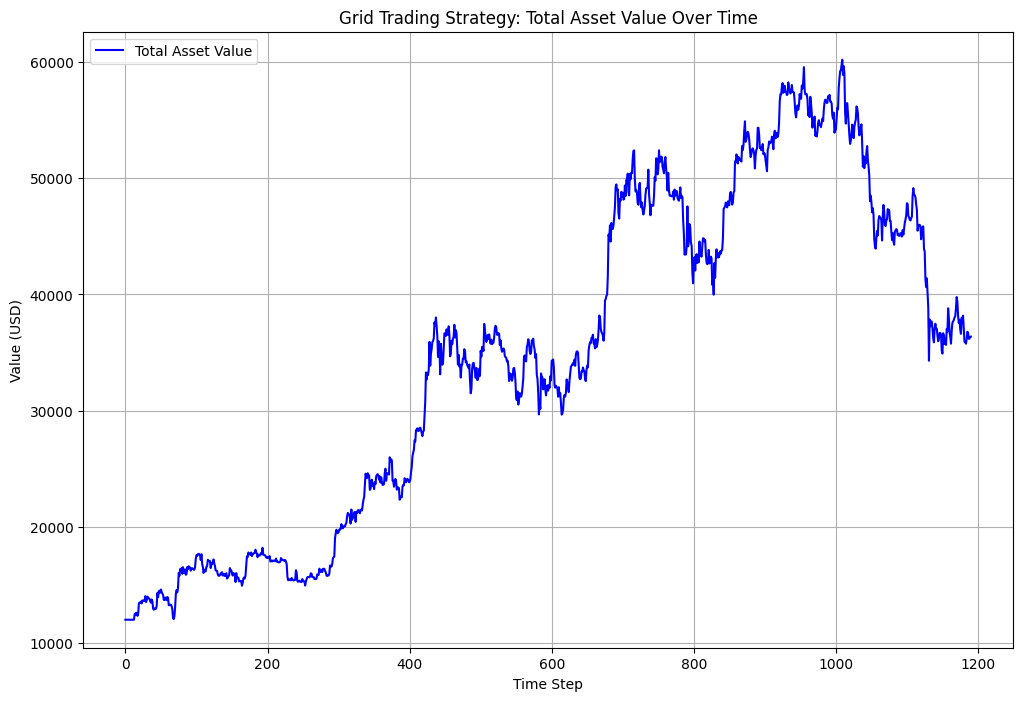

The return rate is 203.04%


In [22]:
last_val = bot.analyze_performance(final_results)